 # Handling Missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Titanic file opened
df = pd.read_csv(r"D:\train.csv")


In [2]:
%matplotlib inline

check data which thing messed

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


overall infomation about data how many column filled by data

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


this is find null value and count null value 

In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

take age and filled with its mean where it is null value

In [7]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [8]:
df['Age'].isna().sum()

np.int64(0)

In [9]:
df['Age'].mean()

np.float64(29.69911764705882)

Take Cabin and see its totally null so i drop it

In [10]:
df.drop('Cabin',axis=1,inplace=True)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


Take embarked and filled with its mode(high frequency) I see it has three category 

In [12]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
df['Embarked'].isna().sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


finally filled total null values so I take categorical data 
age I make its bins which we can fix its age ranges like child, young and senior etc.

In [15]:
df['Age'].max()


np.float64(80.0)

In [16]:
df['Age'].min()

np.float64(0.42)

In [17]:
bin=[0,5,18,35,60,100]

Age ko range me distribute karne ke liye

In [18]:
age_category=pd.cut(df['Age'],bin)
age_category

0      (18, 35]
1      (35, 60]
2      (18, 35]
3      (18, 35]
4      (18, 35]
         ...   
886    (18, 35]
887    (18, 35]
888    (18, 35]
889    (18, 35]
890    (18, 35]
Name: Age, Length: 891, dtype: category
Categories (5, interval[int64, right]): [(0, 5] < (5, 18] < (18, 35] < (35, 60] < (60, 100]]

In [19]:
group_lebel=["child","teenager","Young Adult","Adult","Senior"]
df['Age_group']=pd.cut(df['Age'],bin,labels=group_lebel)

In [20]:
df['Age_group'].value_counts()

Age_group
Young Adult    535
Adult          195
teenager        95
child           44
Senior          22
Name: count, dtype: int64

take Sex column and find unique category 

In [21]:
df['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

male ko 0 and female ko 1 se replace ker diya

In [22]:
df['Sex']=df['Sex'].replace({'male':0,'female':1})

In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_group
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,Young Adult
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,Young Adult


column Embarked has 3 category so not takes 1 and 0 despite get_dummy function
which it makes 3 column its category and put dummy values 

In [24]:
df=pd.get_dummies(df,columns=['Embarked'],prefix='Embar',dtype=int)

In [25]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Age_group,Embar_C,Embar_Q,Embar_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Young Adult,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Adult,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Young Adult,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,Young Adult,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,Young Adult,0,0,1


In [28]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Age_group      0
Embar_C        0
Embar_Q        0
Embar_S        0
dtype: int64

In [29]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    str     
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Age_group    891 non-null    category
 11  Embar_C      891 non-null    int64   
 12  Embar_Q      891 non-null    int64   
 13  Embar_S      891 non-null    int64   
dtypes: category(1), float64(2), int64(8), object(1), str(2)
memory usage: 91.7+ KB


categorical data complete so we take  dtypes
transform data int value 

In [31]:
df['Sex']=df['Sex'].astype(int)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    str     
 4   Sex          891 non-null    int64   
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Age_group    891 non-null    category
 11  Embar_C      891 non-null    int64   
 12  Embar_Q      891 non-null    int64   
 13  Embar_S      891 non-null    int64   
dtypes: category(1), float64(2), int64(9), str(2)
memory usage: 91.7 KB


In [33]:
df['Sex'].dtype

dtype('int64')

Overall survival rate

In [35]:
print(f"Over all survival Rate:{df['Survived'].mean()*100:.2f}%")

Over all survival Rate:38.38%


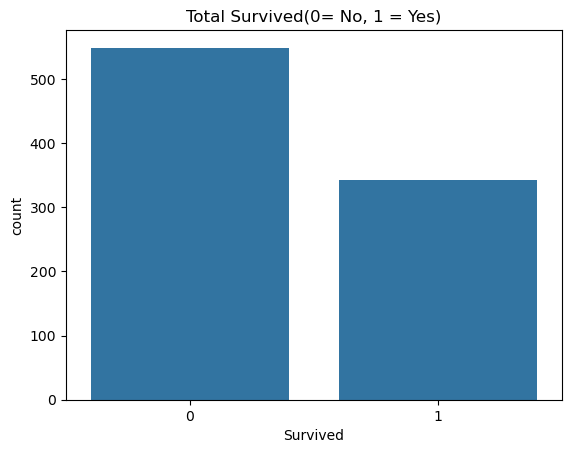

In [36]:
sns.countplot(x='Survived',data=df)
plt.title('Total Survived(0= No, 1 = Yes)')
plt.show()

According to Gender survival Rate

In [37]:
print(df.groupby('Sex')['Survived'].mean())

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64


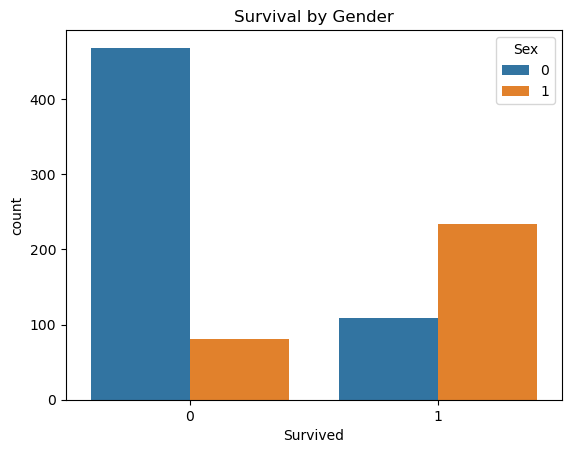

In [38]:
sns.countplot(x='Survived', hue='Sex',data=df)
plt.title('Survival by Gender')
plt.show()

Age group survival 

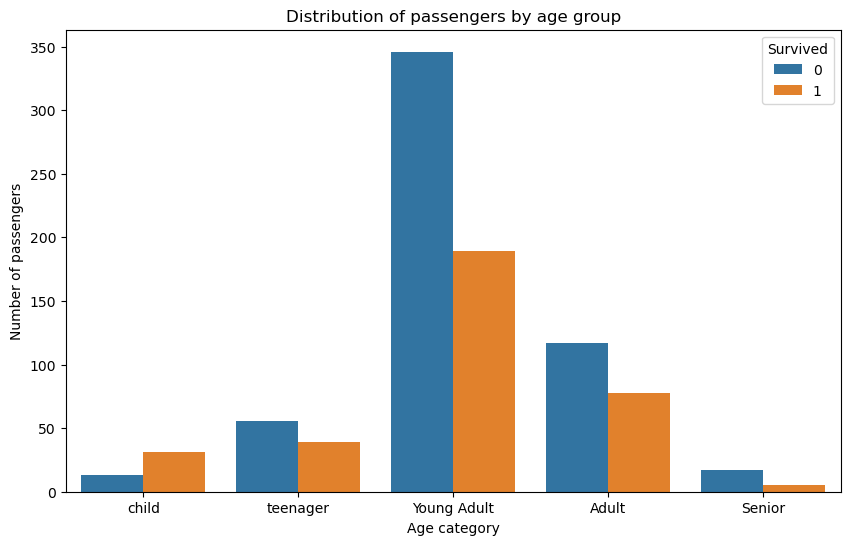

In [39]:
plt.figure(figsize=(10,6))
sns.countplot(x='Age_group',data=df,hue='Survived')
plt.title('Distribution of passengers by age group')
plt.xlabel('Age category')
plt.ylabel('Number of passengers')
plt.show()

In [40]:
df.to_csv('Titanic_cleaned.csv',index=False)